# ASR benchmark: model comparison

Compares every run under `results/` (one folder per model, one CSV per dataset, as written by `run_bench.py`).
The typical question is: **did fine-tuning improve on the base model, and which hyperparameter variant is best?**

Sections:
1. Data coverage: which model was evaluated on which dataset
2. Leaderboard: corpus WER per model and dataset
3. WER per dataset with 95% confidence intervals
4. Relative WER change vs. the baseline
5. Error breakdown: substitutions, deletions, insertions
6. Paired significance: is the difference real or noise?
7. Per-utterance win/tie/loss vs. the baseline
8. WER by utterance length
9. Speed (real-time factor) and speed vs. accuracy
10. Biggest improvements and regressions (qualitative check)

**How WER is computed here.** All WER values are *corpus-level*: total errors / total reference words,
`(S + D + I) / (H + S + D)`, over the normalized text, which gives the same number as `jiwer` and
`evaluate_model.py`. It is **not** the mean of per-utterance WER. That mean over-weights short clips,
where one wrong word can mean 50% WER.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import display

# ---- configuration ---------------------------------------------------------
RESULTS_DIR = Path("../results_2")

# The reference model everything is compared against (a folder name in RESULTS_DIR).
BASELINE = "ivrit-whisper-large-v3-mlx-s"

# Optional: fixed display order / short labels. Models not listed are appended alphabetically.
MODEL_ORDER = [
]
MODEL_LABELS = {
    "ivrit-whisper-large-v3-mlx-s": "baseline (ivrit large-v3) on seeded",
}

N_BOOTSTRAP = 2000  # resamples for confidence intervals / paired tests
RNG = np.random.default_rng(0)

In [2]:
# ---- plot style --------------------------------------------------------------
# Categorical colors in a fixed order (colorblind-validated for up to 3 series together).
# Color follows the model, never its rank, so each model keeps one color in every chart.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
TEXT, TEXT_MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
DIVERGING = ["#2a78d6", "#f0efec", "#e34948"]  # better (blue) <-> neutral <-> worse (red)

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "axes.titlelocation": "left",
    "axes.labelcolor": TEXT_MUTED,
    "axes.edgecolor": GRID,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "axes.axisbelow": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": TEXT_MUTED,
    "ytick.color": TEXT_MUTED,
    "legend.frameon": False,
    "lines.linewidth": 2,
})
pct = mticker.PercentFormatter(xmax=1, decimals=0)

## Load all results

In [3]:
frames = []
for csv in sorted(RESULTS_DIR.glob("*/*.csv")):
    df = pd.read_csv(csv)
    df["model_name"] = csv.parent.name
    df["dataset_name"] = csv.stem
    frames.append(df)

raw = pd.concat(frames, ignore_index=True)
raw["n_ref_words"] = raw["hits"] + raw["substitutions"] + raw["deletions"]
raw["n_errors"] = raw["substitutions"] + raw["deletions"] + raw["insertions"]

found = sorted(raw["model_name"].unique())
MODELS = [m for m in MODEL_ORDER if m in found] + [m for m in found if m not in MODEL_ORDER]
assert BASELINE in MODELS, f"BASELINE {BASELINE!r} not found in {RESULTS_DIR}"
DATASETS = sorted(raw["dataset_name"].unique())
COLOR = {m: PALETTE[i % len(PALETTE)] for i, m in enumerate(MODELS)}
label = lambda m: MODEL_LABELS.get(m, m)

print(f"{len(MODELS)} models, {len(DATASETS)} datasets, {len(raw):,} utterances")

6 models, 5 datasets, 33,094 utterances


## 1. Data coverage
Check this first. A model missing a dataset can't be compared on it, and the averages below only use
datasets that **every** model was evaluated on.

In [4]:
coverage = raw.groupby(["dataset_name", "model_name"]).agg(
    utterances=("id", "size"), hours=("audio_duration", lambda s: s.sum() / 3600)
)
cov_table = coverage["utterances"].unstack()[MODELS].rename(columns=label)
display(cov_table.fillna("missing"))

COMMON_DATASETS = [d for d in DATASETS if coverage.xs(d, level=0).index.nunique() == len(MODELS)]
missing = sorted(set(DATASETS) - set(COMMON_DATASETS))
print("Datasets shared by all models:", COMMON_DATASETS)
if missing:
    print("Excluded from averages (not run on every model):", missing)

# Paired comparisons need the same utterances; flag mismatches.
for d in COMMON_DATASETS:
    ids = [set(raw.query("dataset_name == @d and model_name == @m")["id"]) for m in MODELS]
    if any(s != ids[0] for s in ids):
        print(f"WARNING: {d} has different utterance ids across models")

model_name,ivrit-whisper-large-v3-mlx-c,baseline (ivrit large-v3) on seeded,lv3-mix-b32-kd-low-smooth-mlx-c,lv3-mix-b32-kd-low-smooth-mlx-s,lv3-mix-na-b32-kd-low-smooth-mlx-c,lv3-mix-na-b32-kd-low-smooth-mlx-s
dataset_name,,,,,,
fleurs,792.0,792.0,792.0,792.0,792.0,792.0
hebrew_speech_kan,2000.0,2000.0,2000.0,2000.0,2000.0,missing
ivrit_ai_eval_d1,17.0,17.0,17.0,17.0,17.0,17.0
ivrit_ai_eval_whatsapp,54.0,54.0,54.0,54.0,54.0,54.0
saspeech,2986.0,2986.0,2986.0,2986.0,2986.0,2986.0


Datasets shared by all models: ['fleurs', 'ivrit_ai_eval_d1', 'ivrit_ai_eval_whatsapp', 'saspeech']
Excluded from averages (not run on every model): ['hebrew_speech_kan']


## 2. Leaderboard (corpus WER)
Lower is better. The best model per dataset is highlighted. `avg (macro)` is the plain mean over the shared
datasets, so each dataset counts equally. `avg (pooled)` pools all words together, so large datasets dominate it.

In [5]:
def corpus_wer(df):
    return df["n_errors"].sum() / df["n_ref_words"].sum()

wer = raw.groupby(["dataset_name", "model_name"]).apply(corpus_wer, include_groups=False).unstack()[MODELS]

board = wer.copy()
board.loc["avg (macro)"] = wer.loc[COMMON_DATASETS].mean()
board.loc["avg (pooled)"] = [corpus_wer(raw[(raw.model_name == m) & raw.dataset_name.isin(COMMON_DATASETS)]) for m in MODELS]

display(
    board.rename(columns=label)
    .style.format("{:.2%}", na_rep="n/a")
    .highlight_min(axis=1, props="font-weight: bold; background-color: #cde2fb")
)

model_name,ivrit-whisper-large-v3-mlx-c,baseline (ivrit large-v3) on seeded,lv3-mix-b32-kd-low-smooth-mlx-c,lv3-mix-b32-kd-low-smooth-mlx-s,lv3-mix-na-b32-kd-low-smooth-mlx-c,lv3-mix-na-b32-kd-low-smooth-mlx-s
dataset_name,,,,,,
fleurs,17.69%,21.28%,17.37%,21.21%,17.44%,20.82%
hebrew_speech_kan,8.27%,10.01%,8.28%,9.86%,8.08%,n/a
ivrit_ai_eval_d1,5.05%,6.34%,5.17%,5.85%,5.05%,5.70%
ivrit_ai_eval_whatsapp,7.00%,9.96%,6.76%,9.81%,7.74%,11.81%
saspeech,6.49%,7.18%,6.49%,7.15%,6.45%,7.09%
avg (macro),9.06%,11.19%,8.95%,11.00%,9.17%,11.36%
avg (pooled),8.60%,10.25%,8.52%,10.13%,8.62%,10.26%


## 3. WER per dataset, with 95% confidence intervals
Error bars come from bootstrapping over utterances. **If two models' intervals overlap a lot, the difference
may be noise.** This matters most on small test sets: `ivrit_ai_eval_d1` has only 17 (long) utterances.
Section 6 has the more exact paired test.

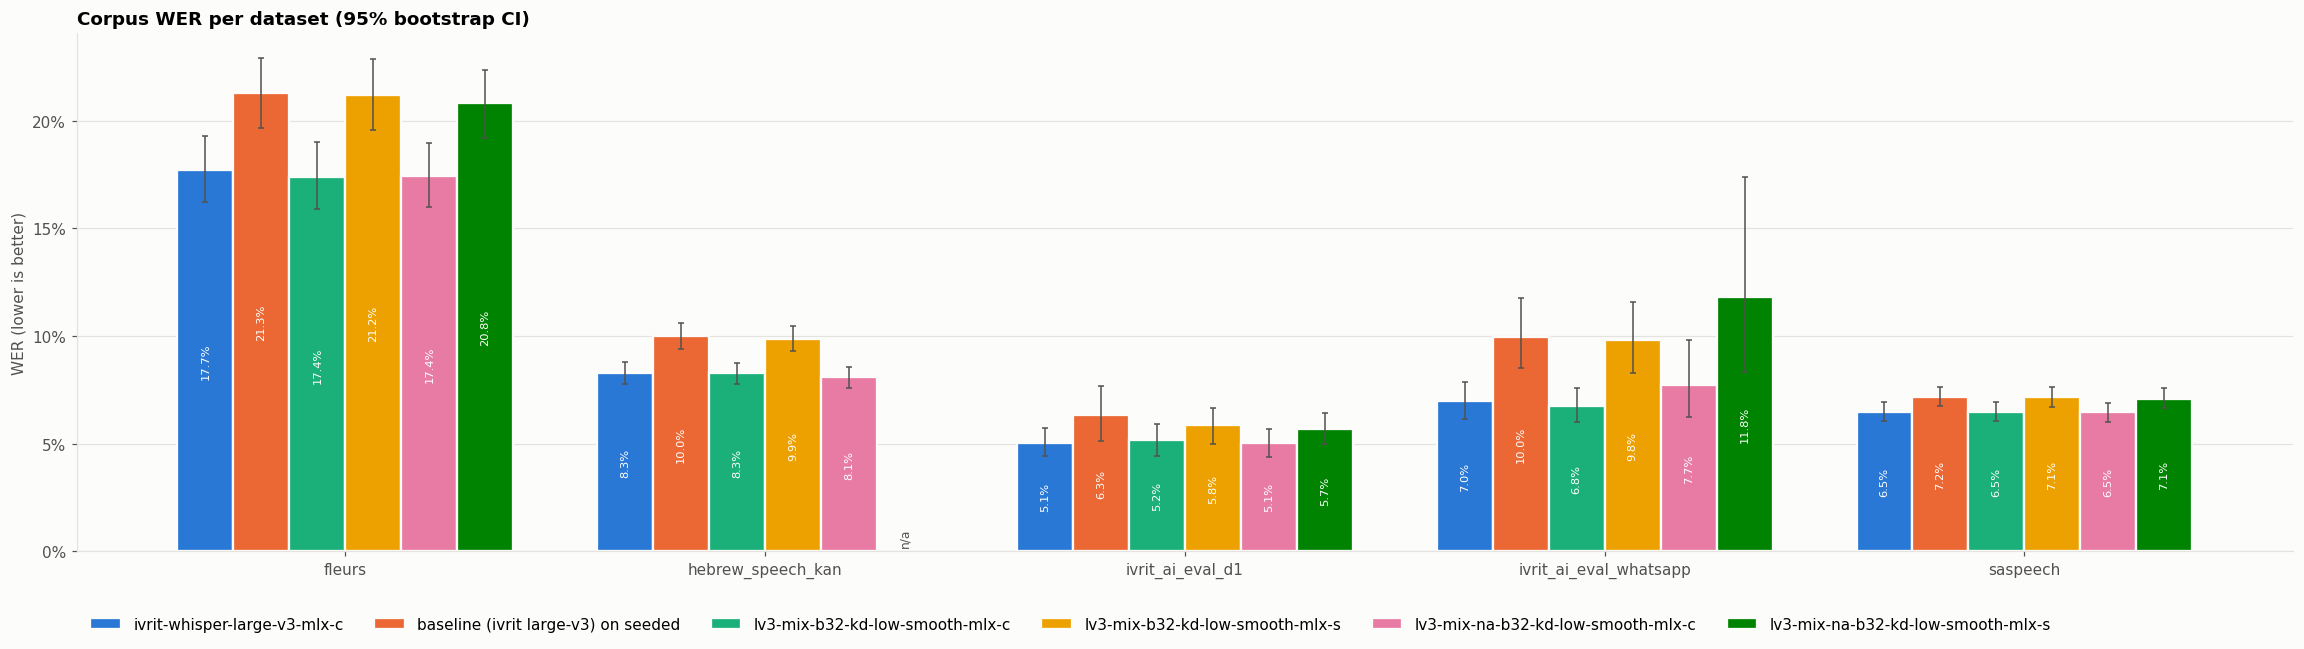

In [17]:
def bootstrap_wer_ci(df, n=N_BOOTSTRAP, alpha=0.05):
    e, w = df["n_errors"].to_numpy(), df["n_ref_words"].to_numpy()
    idx = RNG.integers(0, len(df), size=(n, len(df)))
    samples = e[idx].sum(1) / w[idx].sum(1)
    return np.quantile(samples, [alpha / 2, 1 - alpha / 2])

ci = {
    (d, m): bootstrap_wer_ci(g)
    for (d, m), g in raw.groupby(["dataset_name", "model_name"])
}

fig, ax = plt.subplots(figsize=(22, 6))
width = 0.8 / len(MODELS)
x = np.arange(len(DATASETS))
for i, m in enumerate(MODELS):
    vals = wer.loc[DATASETS, m].to_numpy()
    lo = [vals[j] - ci[(d, m)][0] if (d, m) in ci else 0 for j, d in enumerate(DATASETS)]
    hi = [ci[(d, m)][1] - vals[j] if (d, m) in ci else 0 for j, d in enumerate(DATASETS)]
    pos = x - 0.4 + width * (i + 0.5)
    ax.bar(pos, vals, width, color=COLOR[m], label=label(m), edgecolor=SURFACE, linewidth=1.5)
    ax.errorbar(pos, vals, yerr=[lo, hi], fmt="none", ecolor=TEXT_MUTED, elinewidth=1, capsize=2)
    for p, v in zip(pos, vals):
        if np.isnan(v):
            ax.text(p, 0.002, "n/a", ha="center", va="bottom", fontsize=8, color=TEXT_MUTED, rotation=90)
        else:
            ax.text(p, v / 2, f"{v:.1%}", ha="center", va="center", fontsize=7.5, color="white", rotation=90)
ax.set_xticks(x, DATASETS)
ax.yaxis.set_major_formatter(pct)
ax.set_ylabel("WER (lower is better)")
ax.set_title("Corpus WER per dataset (95% bootstrap CI)")
ax.legend(ncols=len(MODELS), loc="upper left", bbox_to_anchor=(0, -0.1))
plt.tight_layout()
plt.show()

## 4. Relative WER change vs. the baseline
`(WER_model − WER_baseline) / WER_baseline`. **Blue means fewer errors than the baseline and red means more.**
This is the usual way to report fine-tuning gains ("-30% relative WER"), because it makes datasets with very
different absolute WER comparable.

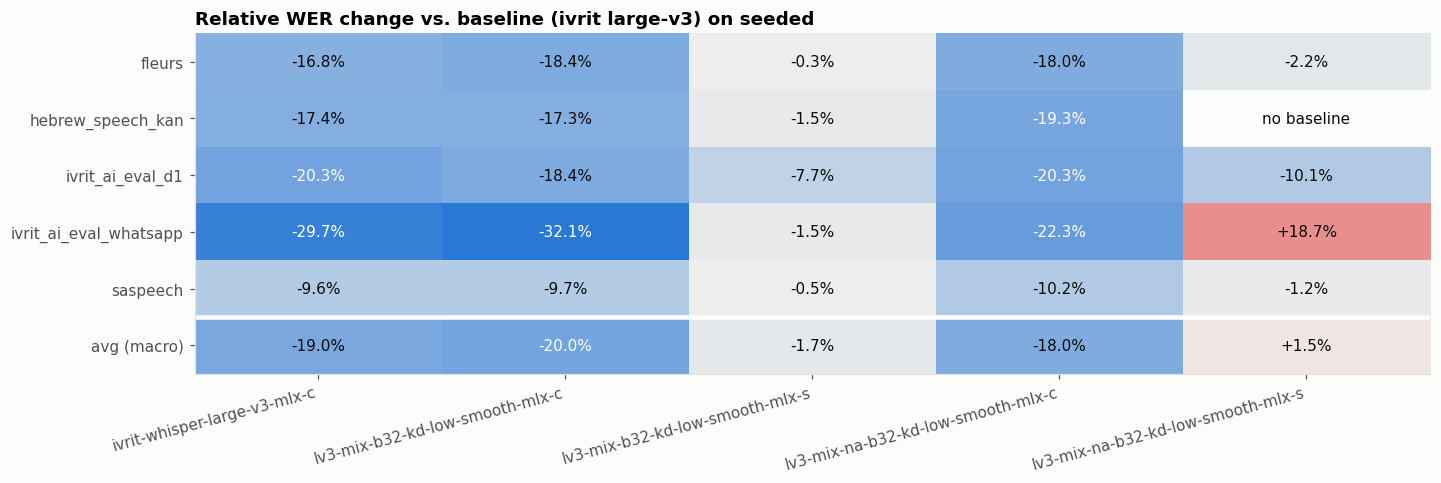

In [7]:
others = [m for m in MODELS if m != BASELINE]
rel = wer[others].sub(wer[BASELINE], axis=0).div(wer[BASELINE], axis=0)
rel.loc["avg (macro)"] = board.loc["avg (macro)", others] / board.loc["avg (macro)", BASELINE] - 1

from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
cmap = LinearSegmentedColormap.from_list("div", DIVERGING)
lim = max(np.nanmax(np.abs(rel.to_numpy())), 0.05)

fig, ax = plt.subplots(figsize=(2.2 + 2.2 * len(others), 0.55 * len(rel) + 1.2))
ax.imshow(rel.to_numpy(dtype=float), cmap=cmap, norm=TwoSlopeNorm(0, -lim, lim), aspect="auto")
for (r, c), v in np.ndenumerate(rel.to_numpy(dtype=float)):
    txt = "no baseline" if np.isnan(v) else f"{v:+.1%}"
    strong = not np.isnan(v) and abs(v) > lim * 0.6
    ax.text(c, r, txt, ha="center", va="center", color="white" if strong else TEXT, fontsize=10)
ax.set_xticks(range(len(others)), [label(m) for m in others], rotation=15, ha="right")
ax.set_yticks(range(len(rel)), rel.index)
ax.axhline(len(rel) - 1.5, color=SURFACE, linewidth=3)
ax.grid(False)
ax.set_title(f"Relative WER change vs. {label(BASELINE)}")
plt.tight_layout()
plt.show()

## 5. Error breakdown: substitutions, deletions, insertions
Each panel is one error type, as a rate per reference word, so the three panels add up to the WER.
They point to different causes:
- **substitutions**: wrong word (spelling, vocabulary, acoustics)
- **deletions**: words skipped (often truncated or cut-off segments, or skipped repetitions)
- **insertions**: extra words (hallucinations, repeated loops, text in silence)

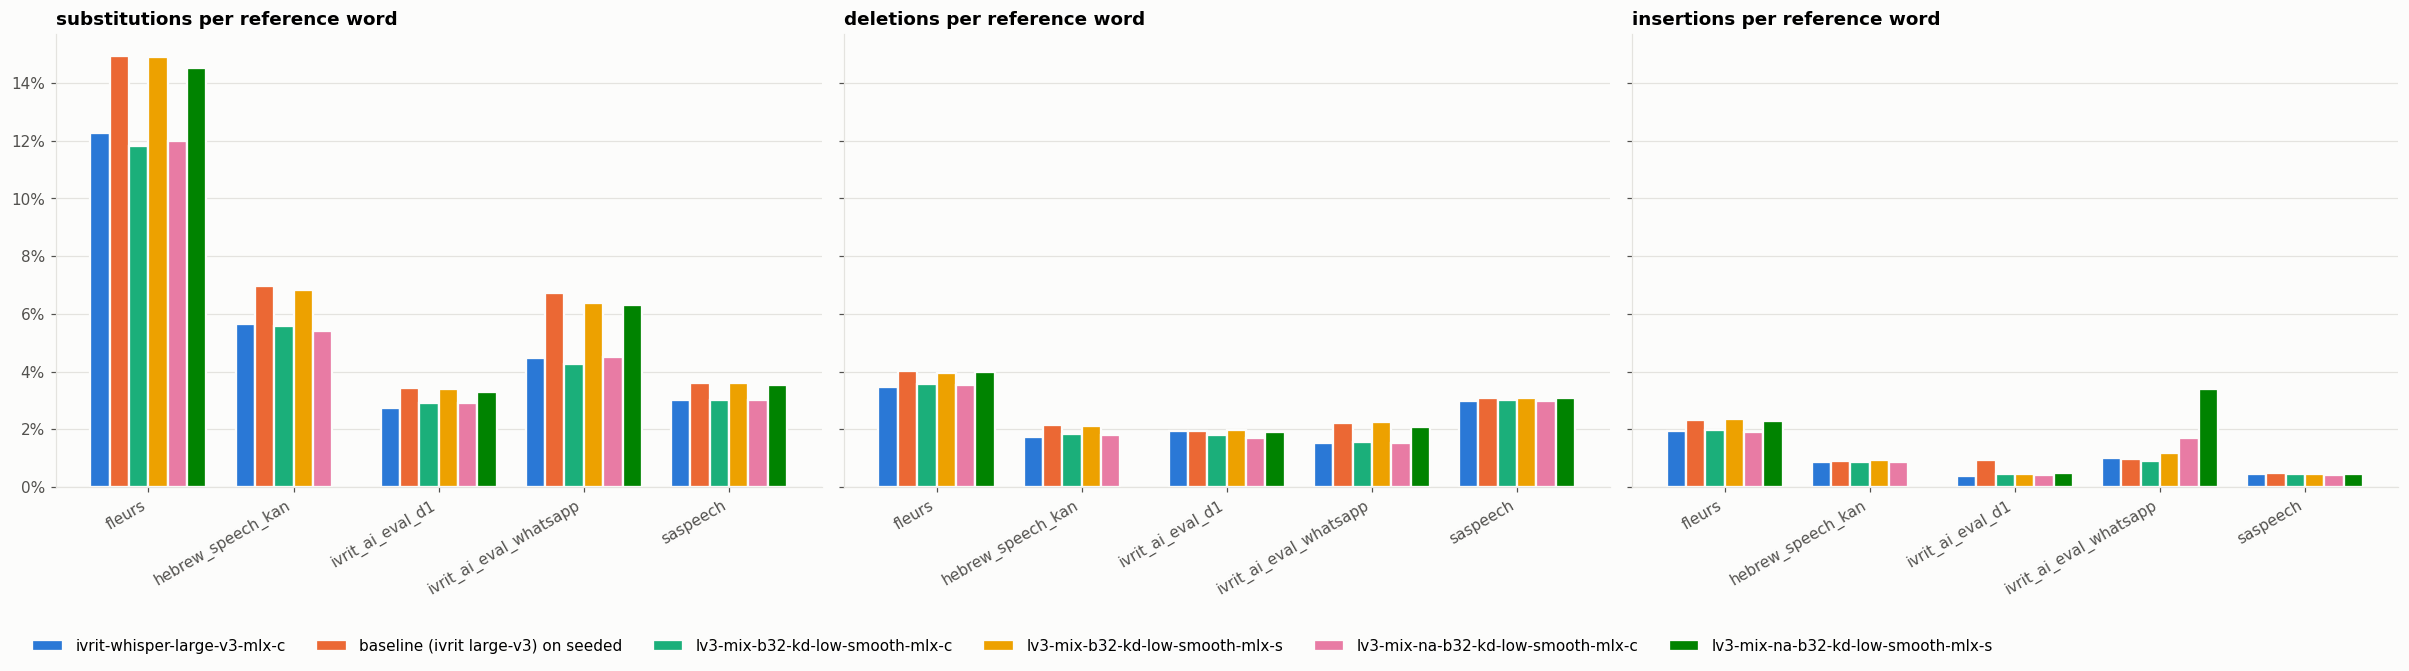

In [19]:
err = raw.groupby(["dataset_name", "model_name"])[["substitutions", "deletions", "insertions", "n_ref_words"]].sum()
for k in ["substitutions", "deletions", "insertions"]:
    err[k + "_rate"] = err[k] / err["n_ref_words"]

fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)

for ax, kind in zip(axes, ["substitutions", "deletions", "insertions"]):
    t = err[kind + "_rate"].unstack().reindex(index=DATASETS, columns=MODELS)
    for i, m in enumerate(MODELS):
        ax.bar(x - 0.4 + width * (i + 0.5), t[m], width, color=COLOR[m], label=label(m), edgecolor=SURFACE, linewidth=1.5)
    ax.set_xticks(x, DATASETS, rotation=30, ha="right")
    ax.set_title(f"{kind} per reference word")
    ax.yaxis.set_major_formatter(pct)
fig.legend(*axes[0].get_legend_handles_labels(), ncols=len(MODELS), loc="lower left", bbox_to_anchor=(0.01, -0.02))
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

## 6. Paired significance test
Every model transcribed the **same** utterances, so a *paired* bootstrap is the standard test for ASR
(Bisani & Ney, 2004). It resamples utterances and recomputes the WER difference each time.
- `ΔWER`: absolute WER difference, row model minus column model (negative means the row model is better)
- `95% CI`: if it doesn't include 0, the difference is significant
- `p(better)`: fraction of resamples in which the row model wins

This is especially useful for choosing between two hyperparameter variants whose WERs are very close.

In [9]:
def paired_bootstrap(a, b, n=N_BOOTSTRAP):
    # a, b: per-utterance frames for two models on the same dataset
    j = a[["id", "n_errors", "n_ref_words"]].merge(b[["id", "n_errors"]], on="id", suffixes=("_a", "_b"))
    ea, eb, w = j["n_errors_a"].to_numpy(), j["n_errors_b"].to_numpy(), j["n_ref_words"].to_numpy()
    idx = RNG.integers(0, len(j), size=(n, len(j)))
    diff = (ea[idx].sum(1) - eb[idx].sum(1)) / w[idx].sum(1)
    return (ea.sum() - eb.sum()) / w.sum(), np.quantile(diff, [0.025, 0.975]), (diff < 0).mean()

rows = []
for d in DATASETS:
    present = [m for m in MODELS if (d, m) in ci]
    for i, ma in enumerate(present):
        for mb in present[i + 1:]:
            a = raw.query("dataset_name == @d and model_name == @ma")
            b = raw.query("dataset_name == @d and model_name == @mb")
            delta, (lo, hi), p = paired_bootstrap(b, a)  # b − a: negative means b is better
            rows.append({
                "dataset": d, "model": label(mb), "vs": label(ma),
                "ΔWER": delta, "95% CI": f"[{lo:+.2%}, {hi:+.2%}]", "p(better)": p,
                "significant": "yes" if (hi < 0 or lo > 0) else "no",
            })
sig = pd.DataFrame(rows)
display(
    sig.style.format({"ΔWER": "{:+.2%}", "p(better)": "{:.1%}"})
    .map(lambda v: "font-weight: bold" if v == "yes" else "", subset=["significant"])
)

,dataset,model,vs,ΔWER,95% CI,p(better),significant
0,fleurs,baseline (ivrit large-v3) on seeded,ivrit-whisper-large-v3-mlx-c,+3.59%,"[+3.02%, +4.17%]",0.0%,yes
1,fleurs,lv3-mix-b32-kd-low-smooth-mlx-c,ivrit-whisper-large-v3-mlx-c,-0.33%,"[-0.58%, -0.07%]",99.5%,yes
2,fleurs,lv3-mix-b32-kd-low-smooth-mlx-s,ivrit-whisper-large-v3-mlx-c,+3.51%,"[+2.86%, +4.17%]",0.0%,yes
3,fleurs,lv3-mix-na-b32-kd-low-smooth-mlx-c,ivrit-whisper-large-v3-mlx-c,-0.25%,"[-0.52%, +0.01%]",97.2%,no
4,fleurs,lv3-mix-na-b32-kd-low-smooth-mlx-s,ivrit-whisper-large-v3-mlx-c,+3.13%,"[+2.51%, +3.77%]",0.0%,yes
5,fleurs,lv3-mix-b32-kd-low-smooth-mlx-c,baseline (ivrit large-v3) on seeded,-3.91%,"[-4.53%, -3.31%]",100.0%,yes
6,fleurs,lv3-mix-b32-kd-low-smooth-mlx-s,baseline (ivrit large-v3) on seeded,-0.07%,"[-0.40%, +0.27%]",65.7%,no
7,fleurs,lv3-mix-na-b32-kd-low-smooth-mlx-c,baseline (ivrit large-v3) on seeded,-3.84%,"[-4.44%, -3.28%]",100.0%,yes
8,fleurs,lv3-mix-na-b32-kd-low-smooth-mlx-s,baseline (ivrit large-v3) on seeded,-0.46%,"[-0.81%, -0.08%]",99.2%,yes
9,fleurs,lv3-mix-b32-kd-low-smooth-mlx-s,lv3-mix-b32-kd-low-smooth-mlx-c,+3.84%,"[+3.26%, +4.43%]",0.0%,yes


## 7. Per-utterance win / tie / loss vs. the baseline
For each utterance: did the model make fewer errors than the baseline (win), more (loss), or the same (tie)?
This shows whether a WER gain is broad or comes from a few utterances.

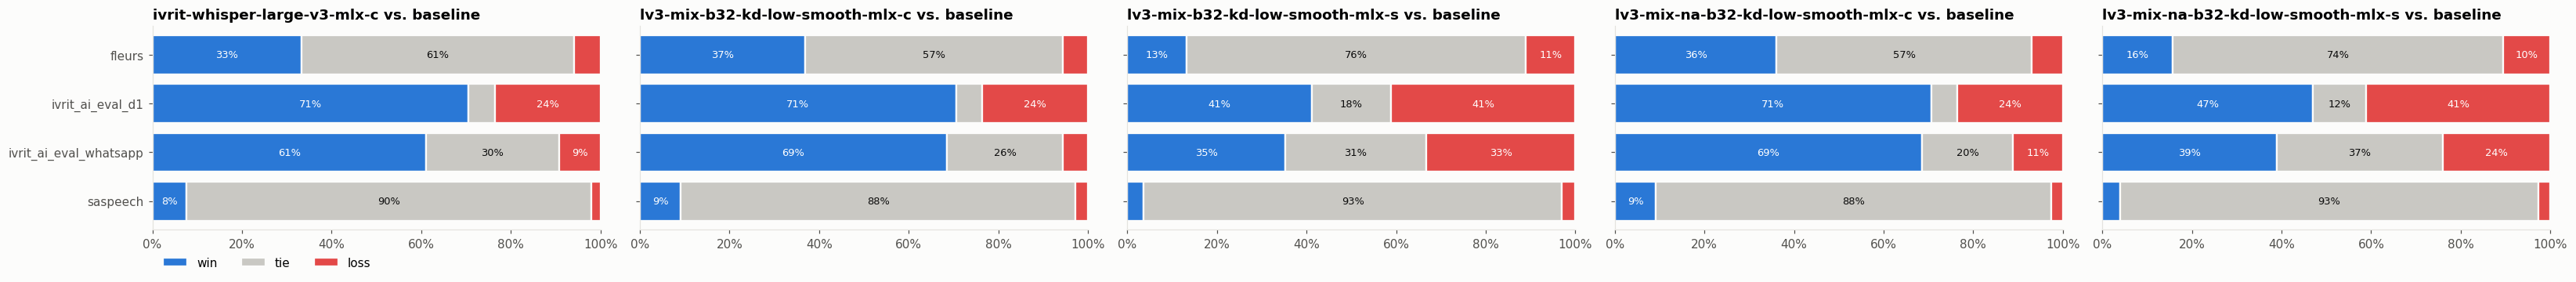

In [10]:
wtl_rows = []
for d in COMMON_DATASETS:
    base = raw.query("dataset_name == @d and model_name == @BASELINE")[["id", "n_errors"]]
    for m in others:
        j = raw.query("dataset_name == @d and model_name == @m")[["id", "n_errors"]].merge(base, on="id", suffixes=("", "_base"))
        diff = j["n_errors"] - j["n_errors_base"]
        wtl_rows.append({"dataset": d, "model": m, "win": (diff < 0).mean(), "tie": (diff == 0).mean(), "loss": (diff > 0).mean()})
wtl = pd.DataFrame(wtl_rows)

fig, axes = plt.subplots(1, len(others), figsize=(6 * len(others), 0.5 * len(COMMON_DATASETS) + 1.4), sharey=True, squeeze=False)
for ax, m in zip(axes[0], others):
    t = wtl[wtl.model == m].set_index("dataset").loc[COMMON_DATASETS]
    left = np.zeros(len(t))
    for col, color in [("win", DIVERGING[0]), ("tie", "#c9c8c3"), ("loss", DIVERGING[2])]:
        ax.barh(t.index, t[col], left=left, color=color, label=col, edgecolor=SURFACE, linewidth=1.5)
        for y, (l, v) in enumerate(zip(left, t[col])):
            if v > 0.07:
                ax.text(l + v / 2, y, f"{v:.0%}", ha="center", va="center", fontsize=8.5,
                        color="white" if col != "tie" else TEXT)
        left += t[col].to_numpy()
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(pct)
    ax.grid(False)
    ax.invert_yaxis()
    ax.set_title(f"{label(m)} vs. baseline")
axes[0][0].legend(ncols=3, loc="upper left", bbox_to_anchor=(0, -0.08))
plt.tight_layout()
plt.show()

## 8. WER by utterance length
Fine-tuning often changes behavior on very short clips (more hallucinations or insertions) or on long ones
(drift, repetition loops). Uses pooled corpus WER per length bucket over the shared datasets. The number of
utterances in each bucket is shown under its label.

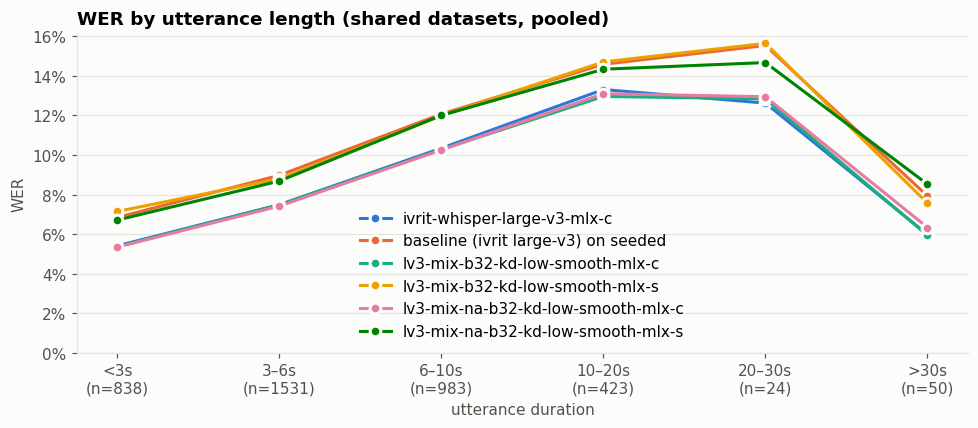

In [11]:
bins = [0, 3, 6, 10, 20, 30, np.inf]
names = ["<3s", "3–6s", "6–10s", "10–20s", "20–30s", ">30s"]
sub = raw[raw.dataset_name.isin(COMMON_DATASETS)].copy()
sub["length"] = pd.cut(sub["audio_duration"], bins=bins, labels=names, right=False)
by_len = sub.groupby(["length", "model_name"], observed=True).apply(corpus_wer, include_groups=False).unstack()[MODELS]
counts = sub[sub.model_name == BASELINE].groupby("length", observed=True).size()

fig, ax = plt.subplots(figsize=(9, 4))
xs = np.arange(len(by_len))
for m in MODELS:
    ax.plot(xs, by_len[m], marker="o", markersize=7, color=COLOR[m], label=label(m),
            markeredgecolor=SURFACE, markeredgewidth=2)
ax.set_xticks(xs, [f"{n}\n(n={counts.get(n, 0)})" for n in by_len.index])
ax.yaxis.set_major_formatter(pct)
ax.set_ylim(bottom=0)
ax.set_xlabel("utterance duration")
ax.set_ylabel("WER")
ax.set_title("WER by utterance length (shared datasets, pooled)")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Speed (not really relevent, since different modes of gpu they should be about the same)
**Real-time factor (RTF)** = transcription time / audio duration. Lower is faster, and 0.25 means 4× faster
than real time. Only compare RTF between runs made on the same machine under similar load
(check `machine.json` in each results folder).

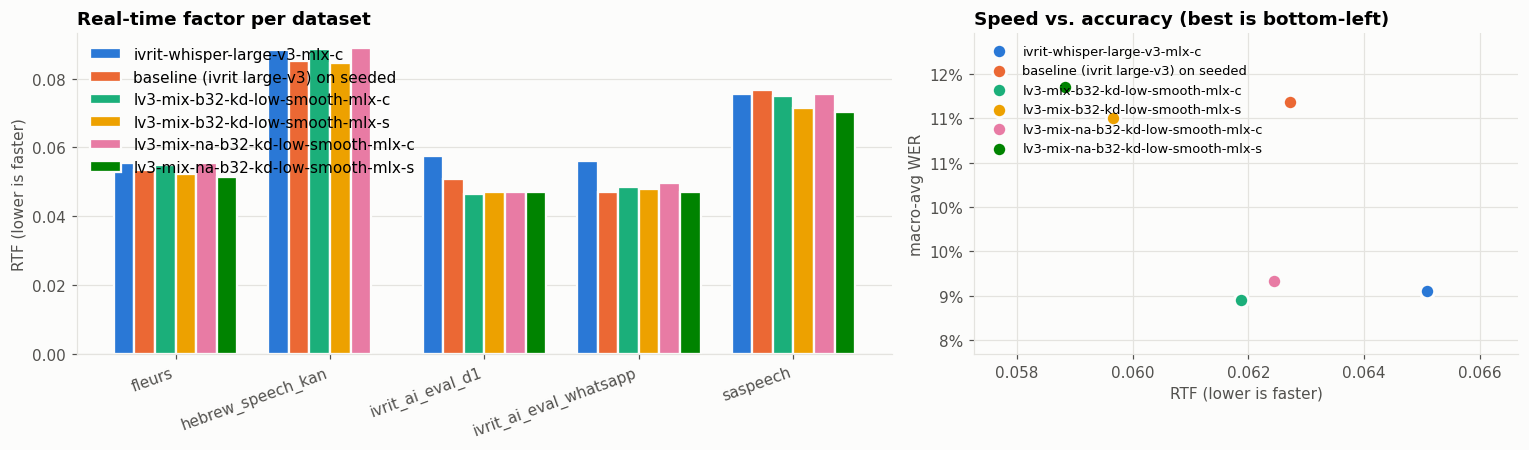

model_name,ivrit-whisper-large-v3-mlx-c,baseline (ivrit large-v3) on seeded,lv3-mix-b32-kd-low-smooth-mlx-c,lv3-mix-b32-kd-low-smooth-mlx-s,lv3-mix-na-b32-kd-low-smooth-mlx-c,lv3-mix-na-b32-kd-low-smooth-mlx-s
dataset_name,,,,,,
fleurs,0.056,0.053,0.055,0.052,0.055,0.052
hebrew_speech_kan,0.088,0.085,0.089,0.084,0.089,n/a
ivrit_ai_eval_d1,0.057,0.051,0.046,0.047,0.047,0.047
ivrit_ai_eval_whatsapp,0.056,0.047,0.049,0.048,0.050,0.047
saspeech,0.076,0.077,0.075,0.072,0.076,0.070


In [12]:
rtf = raw.groupby(["dataset_name", "model_name"]).apply(
    lambda g: g["transcription_time"].sum() / g["audio_duration"].sum(), include_groups=False
).unstack()[MODELS]
rtf_common = sub.groupby("model_name").apply(
    lambda g: g["transcription_time"].sum() / g["audio_duration"].sum(), include_groups=False
)[MODELS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [3, 2]})
for i, m in enumerate(MODELS):
    ax1.bar(x - 0.4 + width * (i + 0.5), rtf.loc[DATASETS, m], width, color=COLOR[m], label=label(m),
            edgecolor=SURFACE, linewidth=1.5)
ax1.set_xticks(x, DATASETS, rotation=20, ha="right")
ax1.set_ylabel("RTF (lower is faster)")
ax1.set_title("Real-time factor per dataset")
ax1.legend(loc="upper left")

for m in MODELS:
    ax2.scatter(rtf_common[m], board.loc["avg (macro)", m], s=90, color=COLOR[m], edgecolor=SURFACE, linewidth=2,
                zorder=3, label=label(m))
ax2.legend(loc="upper left", fontsize=8.5)
ax2.yaxis.set_major_formatter(pct)
ax2.set_xlabel("RTF (lower is faster)")
ax2.set_ylabel("macro-avg WER")
ax2.set_title("Speed vs. accuracy (best is bottom-left)")
ax2.grid(True, axis="both")
ax2.margins(0.25)
plt.tight_layout()
plt.show()

display(rtf.rename(columns=label).style.format("{:.3f}", na_rep="n/a"))

## 10. Biggest improvements and regressions (qualitative)
Metrics don't tell you *what* changed, so read the actual transcripts. Pick a model and a dataset. The table
lists the utterances where it gained or lost the most errors vs. the baseline.

In [23]:
COMPARE_MODEL = others[4]
COMPARE_DATASET = COMMON_DATASETS[0]
TOP_N = 8

cols = ["id", "norm_reference_text", "norm_predicted_text", "n_errors", "audio_duration"]
a = raw.query("dataset_name == @COMPARE_DATASET and model_name == @BASELINE")[cols]
b = raw.query("dataset_name == @COMPARE_DATASET and model_name == @COMPARE_MODEL")[cols[:1] + cols[2:4]]
j = a.merge(b, on="id", suffixes=("_base", "_model"))
j["Δerrors"] = j["n_errors_model"] - j["n_errors_base"]
j = j.rename(columns={"norm_reference_text": "reference", "norm_predicted_text_base": "baseline", "norm_predicted_text_model": "model"})
show = ["id", "Δerrors", "reference", "baseline", "model", "audio_duration"]

with pd.option_context("display.max_colwidth", 200):
    print(f"{label(COMPARE_MODEL)} vs. baseline on {COMPARE_DATASET}")
    print("\nBiggest improvements:")
    display(j.nsmallest(TOP_N, "Δerrors")[show])
    print("Biggest regressions:")
    display(j.nlargest(TOP_N, "Δerrors")[show])

lv3-mix-na-b32-kd-low-smooth-mlx-s vs. baseline on fleurs

Biggest improvements:


,id,Δerrors,reference,baseline,model,audio_duration
24,24,-4,אתר חדשות הבידור tmz מבין כי הצלם עצר את רכבו בצד השני של שדרות ספולוודה וניסה לצלם את המחסום המשטרתי לפני שחצה את הכביש והמשיך מה שהוביל את שוטר משטרת התנועה של קליפורניה שניהל את מחסום התנועה במ...,מבינתי הצלם עצר את רכבו בצד השני של שדרות ספולוודל וניסה לצלם את המחסום המשטרתי לפני שחצה את הכביש והמשיך באתי עם זי אתר חדשות הבידור שהוביל את השוטר משטרת התנועה של קליפורניה שניהל את המחסום בתנ...,מבין כי הצלם עצר את רכבו בצד השני של שדרות ספוואדה וניסה לצלם את המחסום המשטרתי לפני שחצה את הכביש והמשיך בהתאם זה אתר חדשות הבידור שהוביל את השוטר משטרת התנועה של קליפורניה שניהל את המחסום בתנוע...,20.52
488,488,-4,כנסיות מסורתיות יותר במקרים רבים מקיימות ליל שימורים של חג הפסחא במוצאי שבת בסוף השבוע של הפסחא והקהילות נוהגות לפצוח בחגיגות בדיוק בחצות לרגל תחיית ישו,כנסיות מסורתיות יותר במקרים רבים מקיימות ליל שימורים ולחג הפסחא במוצא שבת בסוף שבוע של הפסחא והקהילות נוהגות לבצורך וחגיגות בדיוק בחצור לרגל תחיית ישו,כנסיות מסורתיות יותר במקרים רבים מקיימות ליל שימורים של חג הפסחא במוצא שבת בסוף שבוע של הפסחא והקהילות נוהגות לפצוח וחגיגות בדיוק בחצות לרגל תחיית ישו,12.24
502,502,-4,פינלנד היא יעד שיט נהדר ב ארץ אלף האגמים יש גם אלפי איים באגמים ובארכיפלגים של החוף,פינה ביעד שייט נהדר בארץ אלף האגמים יש גם אלפי איים באגמים וארכיטלגיים של החוף,פינלנד היא יעד שיט נהדר בארץ אלף האגמים יש גם אלפי איים באגמים וארכיפלגים של החוף,7.50
19,19,-3,לסין העתיקה הייתה דרך משלה להציג תקופות זמן שונות כל שלב בתולדות סין או כל משפחה שהחזיקה בשלטון הייתה שושלת ייחודית,הסין העתיקה הייתה דרך משלילה להציג תוכנות זמנות שונות כל שנה בתובוצים וכל משפחה שהיא מקבלת זמנות היא שושלת ייחודית,הסין העתיקה הייתה דרך משלילה להציג תקוות זמנות שונות כל שנה בתקופת סין כל משפחה של זמנות זמנות הייתה שושלת ייחודית,5.88
114,114,-3,הוא דק יותר מתחת לימות ועבה יותר מתחת לרמות,הודק יותר מתחת לימות והעביר אותם מתחת לרמות,הוא דק יותר מתחת לימות ועביר יותר מתחת לרמות,3.36
192,192,-3,למרות לעתים קרובות זה רק סטראוטיפ לא מדויק עדיין הדרך הטובה ביותר להסתדר בפריז היא להתנהג למופת כמו מישהו שהוא bien èlevè מחונך היטב זה יקל מאוד להסתובב בעיר,למרות לעיתים קרובות זה לא קצת מוקדם במדויק עדיין הדרך הטובה ביותר להישאר בפריז היא להתנהג למופת כמו מישהו שהוא זה זה יקל מאוד להסתובב בעיר,למרות לעיתים קרובות זה רק התערכת לא מדויק עדיין הדרך הטובה ביותר לסייר בפריז היא להתנהג למופת כמו מישהו שהוא זה זה יקל מאוד להסתובב בעיר,10.20
198,198,-3,כדאי לכם להיוועץ גם בממשלות של מדינות אחרות אך עצתן מיועדת לאזרחים שלהן,כדאי לכם להיוועץ גם בממשלות של מדיניות החוקת החצותן מועילות לאזרחים שלהם,כדאי לכם להיוועץ גם בממשלות של מדינות אחרות החצתן מועלת לאזרחים שלהן,4.80
284,284,-3,nextgen היא מערכת שלטענת ה faa תאפשר למטוסים לטוס נתיבים קצרים יותר ולחסוך מיליוני גלונים של דלק בכל שנה ולצמצם את פליטת הפחמן,נקסט גן היא מערכת שלטענת ה faa תאפשר למטוסים לטוס בנתיבים קצרים יותר ולחסוך מיליוני גלונים של דלק בכל שנה ולצמצם את פליפת הפחמון,nextgen היא מערכת שלטענת ה faa תאפשר למטוסים לטוס בנתיבים קצרים יותר ולחסוך מיליוני גלונים של דלק בכל שנה ולצמצם את פליטת הפחמון,11.64


Biggest regressions:


,id,Δerrors,reference,baseline,model,audio_duration
23,23,11,פצצת ההיתוך פועלת על פי העיקרון שצריך אנרגיה כדי להרכיב גרעין עם פרוטונים וניוטרונים רבים,צצת ההיתוך פועלת על פי העיקרון שצריך אנרגיה כדי להרכיב גרעין עם פרוטונים וניוטרונים רבים,פרוטונים וניוטרונים רבים פרוטונים וניוטרונים רבים,9.30
65,65,5,ארגון ההתעמלות של ארצות הברית תומך במכתב הוועד האולימפי בארה ב ומקבל את הצורך המוחלט של המשפחה האולימפית לקדם סביבה בטוחה עבור כל הספורטאים שלנו,ארגון ההתעמלות של ארצות הברית תומך במכתב הוועד האולימפי בארצות הברית ומקבל את הצורך המוחלט של המשפחה האולימפית לקדם סביבה בטוחה עבור כל ספורטאיון שלנו,ארגון ההתעמלות של ארה ב תומך במכתב הוועדה האולימפית בארה ב ומקבל את הצורך המוחלט של המשפחה האולימפית לקדם את הסביבה הבטוחה עבור כל ספורטאים שלנו,9.36
130,130,3,מושל קליפורניה ארנולד שוורצנגר חתם על חוק האוסר מכירה או השכרה של משחקי וידאו אלימים לקטינים,מושל קליפורניה ארנולד שוואנצגר חתם על החוק האוסר מכירה או השכרה של משחקי וידאו אלימים לקטינים,מושל קליפורניה ארנולד שוואנסגר חתם על החוק האוסר מכירה או השכרה של משחקי וידאו על מי הם לקטינים,5.64
189,189,3,בירת מולדובה היא קישינב השפה המקומית היא רומנית אך השפה הרוסית נפוצה מאוד,בירת מולדה והיא קישנב השפה המקומית היא רומנית אך השפה הרוסית היא חוצה לאות,בירת מולדה והיא קישנב הסבה המקומית היא רומנית אך הסבה הראשית היא חוצה לאות,9.84
413,413,3,לבסוף ישנם חתולים קטנים רבים כולל חתולי מחמד משוחררים שאוכלים את החיות הקטנות שמספרן גדול בהרבה כמו חרקים מכרסמים לטאות וציפורים,לבסוף ישנם חתולים קטנים רבית סוגריים כולל חתולי מחמד משוחררים שאוכלים את החיות הקטנות שמספרן גדול בהרבה כמו חרקים מכרסמים נטעות וציפורים,לבסוף ישנם חתולים קטנים רבית סוגריים כולל חתולי מחמד משוחררים חגור סוגריים שאוכלים את החיות הקטנות שמספרם גדול בהרבה כמו חרקים מכרסמים נטעות וציפורים,13.80
26,26,2,נשים מומלץ לכל מטיילת לומר שהיא נשואה ללא קשר למצבה המשפחתי בפועל,נשים המלצת לכל מתעיינת לומר שהיא נשואה ללא קשר למצבה המשפחתי בפועל,נשים המלץ לכל מתעיינת לומר שהיא נשואה ללא קשר למצבה המשפחתי או הפועל,5.76
47,47,2,בשנת 2002 נהרסה גומה על ידי לבה מהר הגעש ניראגונגו שקברה את מרבית רחובות העיר ובמיוחד את מרכז העיר,בשנת 2002 נעשה גומה על ידי לבא מהרגש נרגון שקבר את מרבית רחובות העיר ובמיוחד את מרכז העיר,בשנת 2002 נעשה גומאה על ידי לבא מהרגש נרגון שקבר את מרבית רחובות העיר במיוחד את מרכז העיר,5.70
133,133,2,הפארק הלאומי אגמי פליטביצה מיוער בצפיפות בעיקר עצי אשור אשוחית ואשוח ומכיל תערובת של צמחייה אלפינית וים תיכונית,הברק הלאומי עגמי בליטיבציה מיועד בצבאות בעיקר עצי אשוחית ואשוח ומכיל תערובת של צמחיה אלבנית וים תיכונית,הברק הלאומי עגמי בליטיבציה מיועד בצבאות בעיקר עצי אישוח אישוחית ואישוח ומכיל תערובת של צמחיה אלבנית וים תיכונית,19.68
